# 04 - Transfer learning

Notebook consacre a ResNet50, EfficientNet et au fine tuning.

In [1]:
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMAGE_SIZE = (224, 224)


def build_transfer_model(backbone_name='resnet50', input_shape=(224, 224, 3), weights='imagenet'):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    if backbone_name.lower() == 'resnet50':
        backbone_builder = keras.applications.ResNet50
        preprocess = keras.applications.resnet.preprocess_input
    else:
        backbone_builder = keras.applications.EfficientNetB0
        preprocess = keras.applications.efficientnet.preprocess_input

    try:
        backbone = backbone_builder(include_top=False, weights=weights, input_shape=input_shape)
    except Exception:
        backbone = backbone_builder(include_top=False, weights=None, input_shape=input_shape)
        print('Chargement ImageNet indisponible, fallback vers weights=None.')

    backbone.trainable = False
    x = preprocess(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = keras.Model(inputs, outputs, name=f'{backbone_name}_transfer')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mae', metrics=['mae', 'mse'])
    return model, backbone


def unfreeze_last_layers(backbone_model, n_layers=20):
    backbone_model.trainable = True
    for layer in backbone_model.layers[:-n_layers]:
        layer.trainable = False


print('Fonctions de transfer learning pretes pour entrainement et fine tuning.')

Fonctions de transfer learning pretes pour entrainement et fine tuning.


## Chargement des donnees

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

ROOT_DIR = Path.cwd().parents[0]
DATA_DIR = ROOT_DIR / 'data'
BATCH_SIZE = 16
SEED = 42

csv_path = DATA_DIR / 'boneage-training-dataset.csv'
df = pd.read_csv(csv_path)

train_img_dir = DATA_DIR / 'boneage-training-dataset' / 'boneage-training-dataset'
df['filepath'] = df['id'].apply(lambda x: str(train_img_dir / f'{x}.png'))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)
print(f'Train: {len(train_df)}, Val: {len(val_df)}')

Train: 10088, Val: 2523


In [3]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)
    return img, label

train_paths = train_df['filepath'].tolist()
train_labels = train_df['boneage'].astype('float32').tolist()
val_paths = val_df['filepath'].tolist()
val_labels = val_df['boneage'].astype('float32').tolist()

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Train: {train_ds}, Val: {val_ds}')

Train: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>, Val: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## Phase 1: Entrainement avec backbone gele

In [4]:
# construire le modele EfficientNet
model, backbone = build_transfer_model(backbone_name='efficientnet', input_shape=(224, 224, 3), weights='imagenet')
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
# phase 1: backbone gele
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 265s 404ms/step - loss: 38.7602 - mae: 38.7602 - mse: 2496.2986 - val_loss: 34.0292 - val_mae: 34.0292 - val_mse: 1843.2396
Epoch 2/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 254s 398ms/step - loss: 34.6707 - mae: 34.6707 - mse: 1879.4231 - val_loss: 34.0819 - val_mae: 34.0819 - val_mse: 1874.1355
Epoch 3/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 254s 398ms/step - loss: 34.3291 - mae: 34.3291 - mse: 1850.0886 - val_loss: 34.2975 - val_mae: 34.2975 - val_mse: 1915.1936
Epoch 4/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 253s 397ms/step - loss: 34.2890 - mae: 34.2890 - mse: 1845.9615 - val_loss: 34.5157 - val_mae: 34.5157 - val_mse: 1771.5719


## Phase 2: Fine-tuning

In [6]:
# degeber les dernieres couches
unfreeze_last_layers(backbone, n_layers=20)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='mae',
    metrics=['mae', 'mse']
)
print('Fine-tuning des dernieres 20 couches')

Fine-tuning des dernieres 20 couches


In [7]:
# phase 2: fine-tuning
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 278s 425ms/step - loss: 45.1352 - mae: 45.1352 - mse: 3348.1377 - val_loss: 34.6693 - val_mae: 34.6693 - val_mse: 2000.4197
Epoch 2/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 271s 425ms/step - loss: 34.4658 - mae: 34.4658 - mse: 1866.0394 - val_loss: 34.4809 - val_mae: 34.4809 - val_mse: 1954.9362
Epoch 3/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 270s 424ms/step - loss: 34.3135 - mae: 34.3135 - mse: 1848.5591 - val_loss: 34.2350 - val_mae: 34.2350 - val_mse: 1902.8827
Epoch 4/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 271s 425ms/step - loss: 34.3726 - mae: 34.3726 - mse: 1859.1511 - val_loss: 34.3004 - val_mae: 34.3004 - val_mse: 1916.1624
Epoch 5/5
631/631 ━━━━━━━━━━━━━━━━━━━━ 270s 424ms/step - loss: 34.3678 - mae: 34.3678 - mse: 1864.7350 - val_loss: 34.3138 - val_mae: 34.3138 - val_mse: 1919.1088


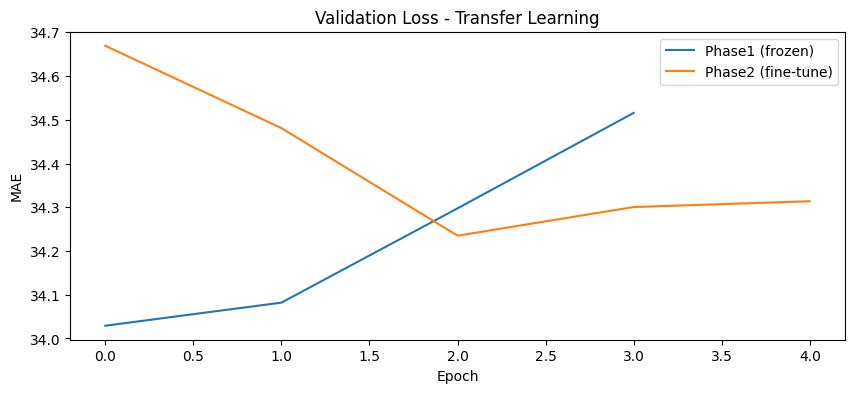

MAE final (transfer learning): 34.24 mois


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

plt.figure(figsize=(10, 4))
plt.plot(history_phase1.history['val_loss'], label='Phase1 (frozen)')
plt.plot(history_phase2.history['val_loss'], label='Phase2 (fine-tune)')
plt.title('Validation Loss - Transfer Learning')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

y_pred = model.predict(val_ds, verbose=0).flatten()
y_true = np.array(val_labels)
mae = mean_absolute_error(y_true, y_pred)
print(f'MAE final (transfer learning): {mae:.2f} mois')